# MQTT IDS — XGBoost v5
**Thay đổi so với v4:**
- ✅ FIX: Parse `tcp.flags` từ hex-string → int64 (nguyên nhân gây `ValueError: DataFrame.dtypes for data must be int, float...`)
- ✅ FIX: Cập nhật `TRAIN_PATH` / `TEST_PATH` đúng theo Kaggle
- ✅ FIX: Auto-detect tên cột label (`target` hoặc `Attack_label`)
- ✅ FIX: Ép kiểu numeric toàn bộ feature columns trước khi train
- ✅ Giữ nguyên logic v4: RandomUnderSampler, không SMOTE, feature engineering rolling window

In [7]:
# ── 1. IMPORTS ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, time, os, pickle
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier

print('All imports OK')

All imports OK


In [8]:
# ── 2. PATHS & CONFIG ─────────────────────────────────────────────────────────
BASE_DIR   = '/kaggle/input/datasets/cnrieiit/mqttset/Data/FINAL_CSV'
TRAIN_PATH = f'{BASE_DIR}/train70_augmented.csv'
TEST_PATH  = f'{BASE_DIR}/test30_augmented.csv'

# Tên cột label — script sẽ auto-detect bên dưới
TARGET = None   # để None → auto-detect

print(f'Train path : {TRAIN_PATH}')
print(f'Test path  : {TEST_PATH}')

Train path : /kaggle/input/datasets/cnrieiit/mqttset/Data/FINAL_CSV/train70_augmented.csv
Test path  : /kaggle/input/datasets/cnrieiit/mqttset/Data/FINAL_CSV/test30_augmented.csv


In [9]:
# ── 3. FEATURE DEFINITIONS ────────────────────────────────────────────────────
BASE_FEATURES = [
    'tcp.len',
    'tcp.time_delta',
    'tcp.flags',           # ← sẽ được parse hex→int ở bước preprocessing
    'mqtt.msgtype',
    'mqtt.msgid',
    'mqtt.qos',
    'mqtt.dupflag',
    'mqtt.len',
    'mqtt.kalive',
    'mqtt.conack.val',
    'mqtt.conflag.passwd',
    'mqtt.retain',
]

ENGINEERED_FEATURES = [
    'time_delta_mean',
    'time_delta_std',
    'pkt_rate',
    'pub_to_conn_ratio',
]

ALL_FEATURES = BASE_FEATURES + ENGINEERED_FEATURES
print(f'Total features: {len(ALL_FEATURES)}')
print(ALL_FEATURES)

Total features: 16
['tcp.len', 'tcp.time_delta', 'tcp.flags', 'mqtt.msgtype', 'mqtt.msgid', 'mqtt.qos', 'mqtt.dupflag', 'mqtt.len', 'mqtt.kalive', 'mqtt.conack.val', 'mqtt.conflag.passwd', 'mqtt.retain', 'time_delta_mean', 'time_delta_std', 'pkt_rate', 'pub_to_conn_ratio']


In [10]:
# ── 4. LOAD DATA ──────────────────────────────────────────────────────────────
print('Loading train set...')
t0 = time.time()
df_train = pd.read_csv(TRAIN_PATH)
print(f'  Train loaded: {len(df_train):,} rows  ({time.time()-t0:.1f}s)')
print(f'  Columns: {list(df_train.columns)}')

print('\nLoading test set...')
t0 = time.time()
df_test = pd.read_csv(TEST_PATH)
print(f'  Test loaded : {len(df_test):,} rows  ({time.time()-t0:.1f}s)')

Loading train set...
  Train loaded: 14,000,000 rows  (45.9s)
  Columns: ['tcp.flags', 'tcp.time_delta', 'tcp.len', 'mqtt.conack.flags', 'mqtt.conack.flags.reserved', 'mqtt.conack.flags.sp', 'mqtt.conack.val', 'mqtt.conflag.cleansess', 'mqtt.conflag.passwd', 'mqtt.conflag.qos', 'mqtt.conflag.reserved', 'mqtt.conflag.retain', 'mqtt.conflag.uname', 'mqtt.conflag.willflag', 'mqtt.conflags', 'mqtt.dupflag', 'mqtt.hdrflags', 'mqtt.kalive', 'mqtt.len', 'mqtt.msg', 'mqtt.msgid', 'mqtt.msgtype', 'mqtt.proto_len', 'mqtt.protoname', 'mqtt.qos', 'mqtt.retain', 'mqtt.sub.qos', 'mqtt.suback.qos', 'mqtt.ver', 'mqtt.willmsg', 'mqtt.willmsg_len', 'mqtt.willtopic', 'mqtt.willtopic_len', 'target']

Loading test set...
  Test loaded : 6,000,000 rows  (19.6s)


In [11]:
# ── 5. AUTO-DETECT LABEL COLUMN ───────────────────────────────────────────────
# Dataset MQTTset dùng 'target' hoặc 'Attack_label' hoặc 'label'
CANDIDATE_LABELS = ['target', 'Attack_label', 'label', 'class', 'attack_type']

if TARGET is None:
    cols_lower = {c.lower(): c for c in df_train.columns}
    for cand in CANDIDATE_LABELS:
        if cand.lower() in cols_lower:
            TARGET = cols_lower[cand.lower()]
            break
    if TARGET is None:
        raise ValueError(
            f'Không tìm được cột label. Các cột hiện có: {list(df_train.columns)}\n'
            'Hãy set tay: TARGET = "tên_cột_label"'
        )

print(f'Label column: "{TARGET}"')
print('\nTrain label distribution (before sampling):')
print(df_train[TARGET].value_counts())

Label column: "target"

Train label distribution (before sampling):
target
legitimate    7000000
bruteforce    1400000
flood         1400000
slowite       1400000
dos           1400000
malformed     1400000
Name: count, dtype: int64


In [12]:
# ── 6. KIỂM TRA & LỌC FEATURES CÓ TRONG DATASET ──────────────────────────────
def filter_available_features(df, features, label):
    """Chỉ giữ lại những feature thực sự có trong df."""
    available = [f for f in features if f in df.columns]
    missing   = [f for f in features if f not in df.columns]
    if missing:
        print(f'  WARNING: {len(missing)} feature(s) không có trong CSV → bỏ qua:')
        for m in missing:
            print(f'    - {m}')
    return available

print('Checking features in train set...')
BASE_FEATURES_OK = filter_available_features(df_train, BASE_FEATURES, TARGET)
print(f'  Base features available: {len(BASE_FEATURES_OK)}/{len(BASE_FEATURES)}')

Checking features in train set...
  Base features available: 12/12


In [13]:
# ── 7. FIX tcp.flags: hex-string → int ───────────────────────────────────────
# XGBoost chỉ nhận int/float/bool/category.
# tcp.flags trong PCAP thường là hex string như '0x002', '0x018'.

def fix_hex_columns(df, col_name):
    """Parse cột hex-string thành int64; nếu đã là số thì ép float."""
    if col_name not in df.columns:
        return df
    col = df[col_name]
    if col.dtype == object:
        print(f'  Parsing {col_name}: object → int64 (hex string detected)')
        # Xử lý cả trường hợp có prefix '0x' và không có
        df[col_name] = col.astype(str).str.strip().apply(
            lambda x: int(x, 16) if x.startswith('0x') or x.startswith('0X')
            else (int(x, 16) if all(c in '0123456789abcdefABCDEF' for c in x.replace('nan','')) and x != 'nan'
                  else np.nan)
        ).astype('float64')  # float64 để handle NaN, XGBoost OK
    else:
        df[col_name] = pd.to_numeric(col, errors='coerce')
    return df

# Áp dụng fix cho cả train & test
for _df_name, _df in [('train', df_train), ('test', df_test)]:
    print(f'--- {_df_name} ---')
    df_train if _df_name == 'train' else df_test  # reference

df_train = fix_hex_columns(df_train, 'tcp.flags')
df_test  = fix_hex_columns(df_test,  'tcp.flags')

print('tcp.flags dtype after fix:')
print(f'  train: {df_train["tcp.flags"].dtype if "tcp.flags" in df_train.columns else "N/A"}')
print(f'  test : {df_test["tcp.flags"].dtype  if "tcp.flags" in df_test.columns  else "N/A"}')

--- train ---
--- test ---
  Parsing tcp.flags: object → int64 (hex string detected)
  Parsing tcp.flags: object → int64 (hex string detected)
tcp.flags dtype after fix:
  train: float64
  test : float64


In [14]:
# ── 8. FEATURE ENGINEERING (rolling window) ───────────────────────────────────
def engineer_features(df, window=50):
    missing = [f for f in ENGINEERED_FEATURES if f not in df.columns]
    if not missing:
        print('  Engineered features already present, skipping.')
        return df
    if 'tcp.time_delta' not in df.columns:
        print('  WARNING: tcp.time_delta not found, skipping engineered features.')
        return df

    print(f'  Computing engineered features (window={window}): {missing}')
    td = pd.to_numeric(df['tcp.time_delta'], errors='coerce').fillna(0)

    df['time_delta_mean'] = td.rolling(window, min_periods=1).mean()
    df['time_delta_std']  = td.rolling(window, min_periods=1).std().fillna(0)
    df['pkt_rate']        = 1.0 / df['time_delta_mean'].replace(0, 1e-9)

    is_pub  = (pd.to_numeric(df.get('mqtt.msgtype', 0), errors='coerce').fillna(0) == 3).astype(float)
    is_conn = (pd.to_numeric(df.get('mqtt.msgtype', 0), errors='coerce').fillna(0) == 1).astype(float)
    pub_roll  = is_pub.rolling(window, min_periods=1).sum()
    conn_roll = is_conn.rolling(window, min_periods=1).sum().replace(0, 1)
    df['pub_to_conn_ratio'] = pub_roll / conn_roll
    return df

print('Engineering train features...')
df_train = engineer_features(df_train)
print('Engineering test features...')
df_test  = engineer_features(df_test)
print('Done.')

Engineering train features...
  Computing engineered features (window=50): ['time_delta_mean', 'time_delta_std', 'pkt_rate', 'pub_to_conn_ratio']
Engineering test features...
  Computing engineered features (window=50): ['time_delta_mean', 'time_delta_std', 'pkt_rate', 'pub_to_conn_ratio']
Done.


In [15]:
# ── 9. XÁC NHẬN FINAL FEATURE LIST ───────────────────────────────────────────
# Sau khi engineer xong, kiểm tra lần cuối feature nào thực sự tồn tại
ALL_FEATURES_OK = [f for f in ALL_FEATURES if f in df_train.columns]
missing_final   = [f for f in ALL_FEATURES if f not in df_train.columns]

if missing_final:
    print(f'Features bị loại khỏi model ({len(missing_final)}): {missing_final}')

print(f'\nFinal feature count: {len(ALL_FEATURES_OK)}')
print(ALL_FEATURES_OK)

# Cập nhật ALL_FEATURES để dùng xuyên suốt
ALL_FEATURES = ALL_FEATURES_OK


Final feature count: 16
['tcp.len', 'tcp.time_delta', 'tcp.flags', 'mqtt.msgtype', 'mqtt.msgid', 'mqtt.qos', 'mqtt.dupflag', 'mqtt.len', 'mqtt.kalive', 'mqtt.conack.val', 'mqtt.conflag.passwd', 'mqtt.retain', 'time_delta_mean', 'time_delta_std', 'pkt_rate', 'pub_to_conn_ratio']


In [16]:
# ── 10. ÉP KIỂU NUMERIC TOÀN BỘ FEATURES ─────────────────────────────────────
# Bước này đảm bảo không còn object dtype nào lọt vào XGBoost

def enforce_numeric(df, features):
    """Ép tất cả feature columns về float64; in ra cảnh báo nếu có object."""
    issues = []
    for col in features:
        if col not in df.columns:
            continue
        if df[col].dtype == object:
            issues.append(col)
            df[col] = pd.to_numeric(df[col], errors='coerce')
    if issues:
        print(f'  Coerced {len(issues)} object column(s) to numeric: {issues}')
    else:
        print('  All feature columns are already numeric. ✓')
    return df

print('Enforcing numeric dtypes — train:')
df_train = enforce_numeric(df_train, ALL_FEATURES)
print('Enforcing numeric dtypes — test:')
df_test  = enforce_numeric(df_test,  ALL_FEATURES)

# Xác nhận
print('\nDtype check (train):')
print(df_train[ALL_FEATURES].dtypes.value_counts())

Enforcing numeric dtypes — train:
  All feature columns are already numeric. ✓
Enforcing numeric dtypes — test:
  All feature columns are already numeric. ✓

Dtype check (train):
float64    15
int64       1
Name: count, dtype: int64


In [17]:
# ── 11. ENCODE LABELS ─────────────────────────────────────────────────────────
le = LabelEncoder()
df_train['label_enc'] = le.fit_transform(df_train[TARGET])
df_test['label_enc']  = le.transform(df_test[TARGET])

print('Classes:', le.classes_)
print('Encoded:', list(range(len(le.classes_))))

Classes: ['bruteforce' 'dos' 'flood' 'legitimate' 'malformed' 'slowite']
Encoded: [0, 1, 2, 3, 4, 5]


In [18]:
# ── 12. UNDERSAMPLE legitimate ONLY ──────────────────────────────────────────
label_counts = df_train['label_enc'].value_counts()
print('Label distribution (encoded):')
for enc_val, cnt in label_counts.items():
    cls_name = le.classes_[enc_val]
    print(f'  [{enc_val}] {cls_name}: {cnt:,}')

# Tìm encoded value của legitimate
try:
    LEGIT_LABEL_ENC = le.transform(['legitimate'])[0]
    print(f'\nlegitimate encoded as: {LEGIT_LABEL_ENC}')
except ValueError:
    print('\nWARNING: "legitimate" not found. Available classes:', le.classes_)
    LEGIT_CLASS_NAME = le.classes_[label_counts.idxmax()]
    LEGIT_LABEL_ENC  = le.transform([LEGIT_CLASS_NAME])[0]
    print(f'Using largest class as majority: {LEGIT_CLASS_NAME} → enc {LEGIT_LABEL_ENC}')

attack_counts = label_counts.drop(LEGIT_LABEL_ENC)
print('\nAttack class counts:')
print(attack_counts.rename(lambda i: le.classes_[i]))

LEGIT_TARGET_COUNT = min(int(attack_counts.max()), 1_400_000)
print(f'\nUndersampling legitimate: {label_counts[LEGIT_LABEL_ENC]:,} → {LEGIT_TARGET_COUNT:,}')

sampling_strategy = {LEGIT_LABEL_ENC: LEGIT_TARGET_COUNT}
rus = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=42)

X_all = df_train[ALL_FEATURES]
y_all = df_train['label_enc']

t0 = time.time()
X_resampled, y_resampled = rus.fit_resample(X_all, y_all)
print(f'Resampling done in {time.time()-t0:.1f}s')
print(f'Train set after undersampling: {len(X_resampled):,} samples')
print('\nLabel distribution after undersampling:')
dist = pd.Series(y_resampled).map(dict(enumerate(le.classes_))).value_counts()
print(dist)

Label distribution (encoded):
  [3] legitimate: 7,000,000
  [0] bruteforce: 1,400,000
  [2] flood: 1,400,000
  [5] slowite: 1,400,000
  [1] dos: 1,400,000
  [4] malformed: 1,400,000

legitimate encoded as: 3

Attack class counts:
label_enc
bruteforce    1400000
flood         1400000
slowite       1400000
dos           1400000
malformed     1400000
Name: count, dtype: int64

Undersampling legitimate: 7,000,000 → 1,400,000
Resampling done in 3.9s
Train set after undersampling: 8,400,000 samples

Label distribution after undersampling:
label_enc
bruteforce    1400000
dos           1400000
flood         1400000
legitimate    1400000
malformed     1400000
slowite       1400000
Name: count, dtype: int64


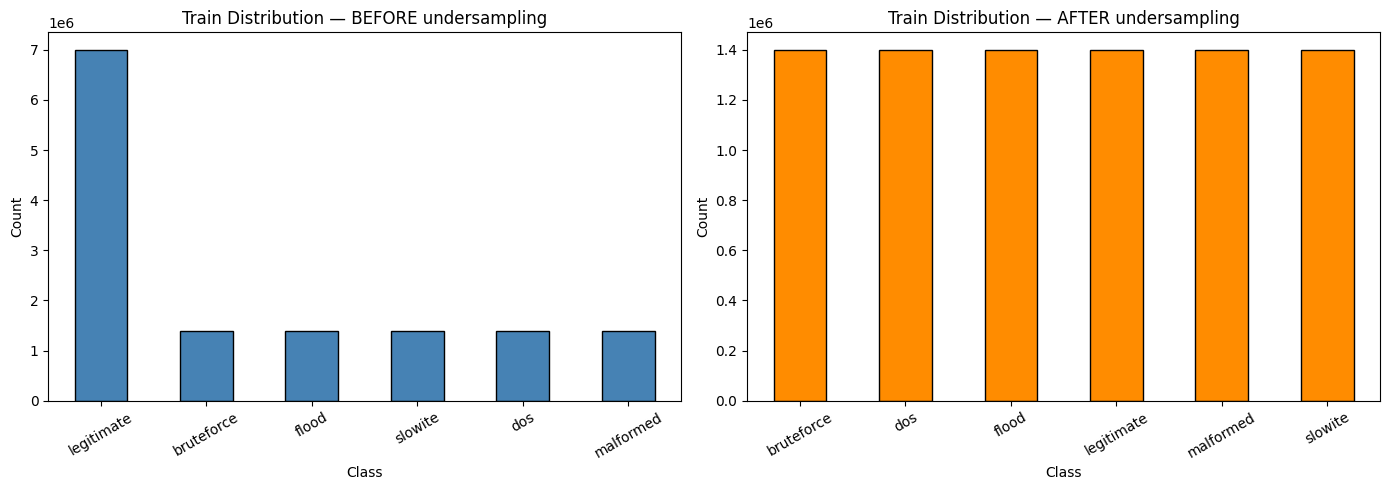

In [19]:
# ── 13. VISUALISE DISTRIBUTION ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

before = df_train[TARGET].value_counts()
before.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Train Distribution — BEFORE undersampling')
axes[0].set_xlabel('Class'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

dist.plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='black')
axes[1].set_title('Train Distribution — AFTER undersampling')
axes[1].set_xlabel('Class'); axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=120)
plt.show()

In [20]:
# ── 14. TRAIN / VALIDATION SPLIT ─────────────────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X_resampled, y_resampled,
    test_size=0.15,
    random_state=42,
    stratify=y_resampled
)
print(f'X_train: {X_train.shape}  |  X_val: {X_val.shape}')

# Đảm bảo X_train/X_val là float (sau resampling có thể thành numpy array)
if hasattr(X_train, 'dtypes'):
    bad_cols = X_train.select_dtypes(include='object').columns.tolist()
    if bad_cols:
        print(f'WARNING: object columns still in X_train: {bad_cols}')
        for c in bad_cols:
            X_train[c] = pd.to_numeric(X_train[c], errors='coerce')
            X_val[c]   = pd.to_numeric(X_val[c],   errors='coerce')

X_train: (7140000, 16)  |  X_val: (1260000, 16)


In [21]:
# ── 15. TRAIN XGBOOST ─────────────────────────────────────────────────────────
model = XGBClassifier(
    n_estimators=400,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective='multi:softmax',
    num_class=len(le.classes_),
    eval_metric='mlogloss',
    early_stopping_rounds=20,
    tree_method='hist',      # nhanh hơn cho dataset lớn
    device='cuda',           # đổi sang 'cpu' nếu không có GPU
    random_state=42,
    n_jobs=-1,
    verbosity=1
)

print('Training XGBoost...')
t0 = time.time()
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)
print(f'Training done in {time.time()-t0:.1f}s')
print(f'Best iteration: {model.best_iteration}')

Training XGBoost...
[0]	validation_0-mlogloss:1.62553
[50]	validation_0-mlogloss:0.45215
[100]	validation_0-mlogloss:0.41944
[150]	validation_0-mlogloss:0.41483
[200]	validation_0-mlogloss:0.41386
[250]	validation_0-mlogloss:0.41357
[300]	validation_0-mlogloss:0.41344
[327]	validation_0-mlogloss:0.41344
Training done in 67.0s
Best iteration: 307


In [22]:
# ── 16. VALIDATION METRICS ────────────────────────────────────────────────────
y_val_pred = model.predict(X_val)

val_acc = accuracy_score(y_val, y_val_pred)
val_f1  = f1_score(y_val, y_val_pred, average='weighted')
print(f'Validation Accuracy      : {val_acc:.4f}')
print(f'Validation F1 (weighted) : {val_f1:.4f}')
print()
print(classification_report(y_val, y_val_pred, target_names=le.classes_))

Validation Accuracy      : 0.8161
Validation F1 (weighted) : 0.8145

              precision    recall  f1-score   support

  bruteforce       0.76      0.78      0.77    210000
         dos       0.91      0.87      0.89    210000
       flood       0.83      0.86      0.84    210000
  legitimate       0.86      0.85      0.86    210000
   malformed       0.87      0.62      0.72    210000
     slowite       0.72      0.91      0.80    210000

    accuracy                           0.82   1260000
   macro avg       0.82      0.82      0.81   1260000
weighted avg       0.82      0.82      0.81   1260000



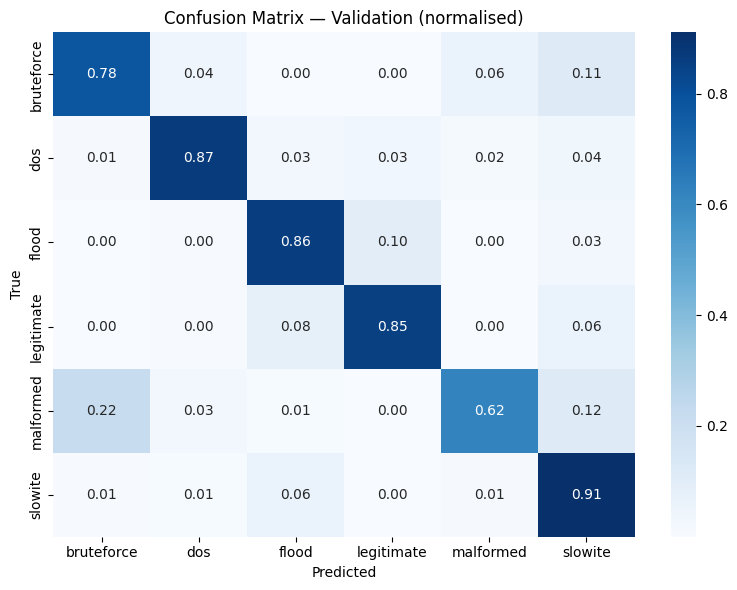

In [23]:
# ── 17. CONFUSION MATRIX (VALIDATION) ────────────────────────────────────────
cm = confusion_matrix(y_val, y_val_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=le.classes_, yticklabels=le.classes_
)
plt.title('Confusion Matrix — Validation (normalised)')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix_val.png', dpi=120)
plt.show()

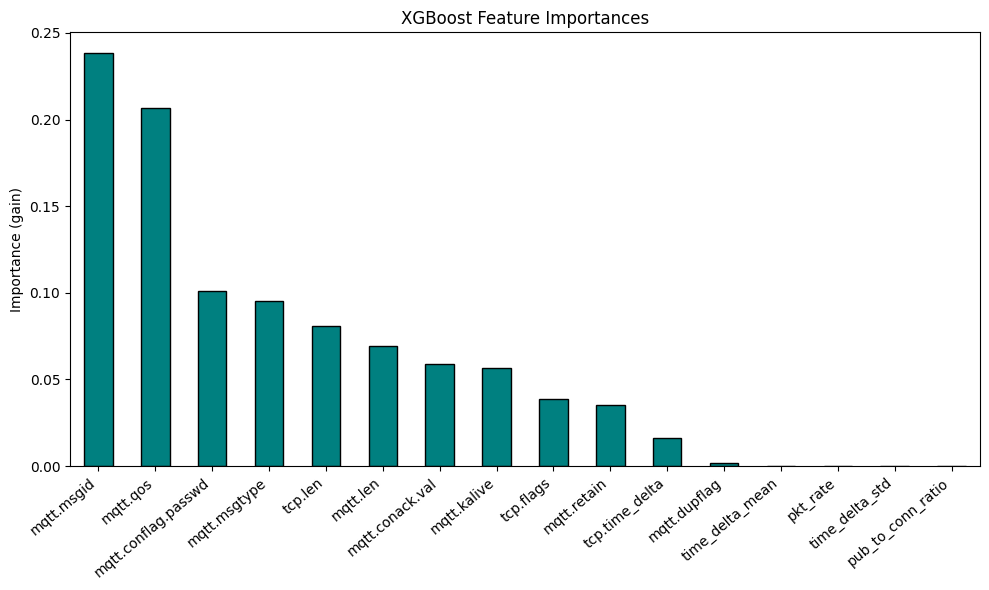

mqtt.msgid             0.238451
mqtt.qos               0.206764
mqtt.conflag.passwd    0.100992
mqtt.msgtype           0.095278
tcp.len                0.080798
mqtt.len               0.069570
mqtt.conack.val        0.058901
mqtt.kalive            0.056816
tcp.flags              0.038720
mqtt.retain            0.035377
tcp.time_delta         0.016317
mqtt.dupflag           0.001819
time_delta_mean        0.000052
pkt_rate               0.000051
time_delta_std         0.000050
pub_to_conn_ratio      0.000045
dtype: float32


In [24]:
# ── 18. FEATURE IMPORTANCE ────────────────────────────────────────────────────
fi = pd.Series(model.feature_importances_, index=ALL_FEATURES).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
fi.plot(kind='bar', color='teal', edgecolor='black')
plt.title('XGBoost Feature Importances')
plt.ylabel('Importance (gain)')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120)
plt.show()
print(fi)

In [25]:
# ── 19. TEST SET EVALUATION (batch predict) ───────────────────────────────────
BATCH_SIZE = 500_000

# Đảm bảo test set cũng numeric
X_test = df_test[ALL_FEATURES].copy()
bad_test = X_test.select_dtypes(include='object').columns.tolist()
if bad_test:
    print(f'Coercing object cols in test set: {bad_test}')
    for c in bad_test:
        X_test[c] = pd.to_numeric(X_test[c], errors='coerce')

y_test = df_test['label_enc']

print(f'Predicting test set ({len(X_test):,} rows) in batches of {BATCH_SIZE:,}...')
preds_list = []
t0 = time.time()
for start in range(0, len(X_test), BATCH_SIZE):
    batch = X_test.iloc[start:start+BATCH_SIZE]
    preds_list.append(model.predict(batch))
    if (start // BATCH_SIZE) % 5 == 0:
        print(f'  {start:,} / {len(X_test):,}  ({time.time()-t0:.0f}s elapsed)')

y_test_pred = np.concatenate(preds_list)
print(f'Prediction done in {time.time()-t0:.1f}s')

test_acc = accuracy_score(y_test, y_test_pred)
test_f1  = f1_score(y_test, y_test_pred, average='weighted')
print(f'\nTest Accuracy      : {test_acc:.4f}')
print(f'Test F1 (weighted) : {test_f1:.4f}')
print()
print(classification_report(y_test, y_test_pred, target_names=le.classes_))

Predicting test set (6,000,000 rows) in batches of 500,000...
  0 / 6,000,000  (0s elapsed)
  2,500,000 / 6,000,000  (2s elapsed)
  5,000,000 / 6,000,000  (4s elapsed)
Prediction done in 4.4s

Test Accuracy      : 0.8324
Test F1 (weighted) : 0.8377

              precision    recall  f1-score   support

  bruteforce       0.76      0.78      0.77    600000
         dos       0.89      0.87      0.88    600000
       flood       0.64      0.86      0.73    600000
  legitimate       0.97      0.86      0.91   3000000
   malformed       0.86      0.62      0.72    600000
     slowite       0.60      0.91      0.72    600000

    accuracy                           0.83   6000000
   macro avg       0.79      0.82      0.79   6000000
weighted avg       0.86      0.83      0.84   6000000



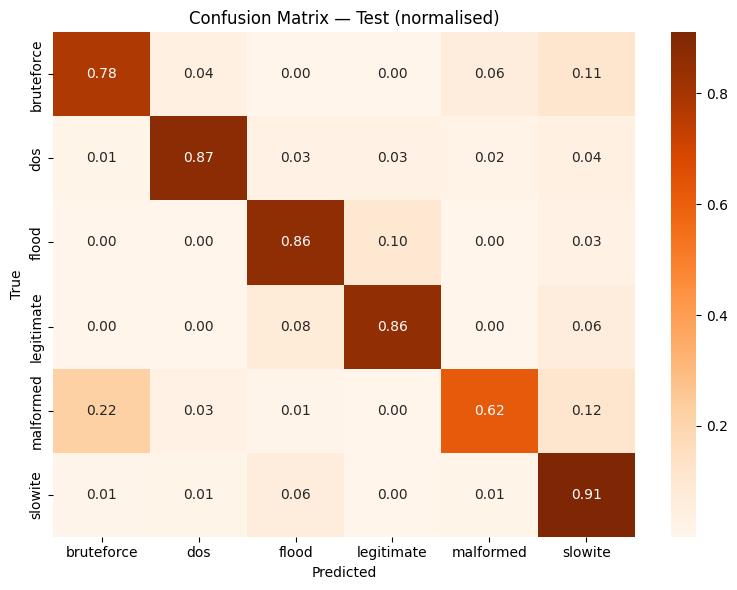

In [26]:
# ── 20. CONFUSION MATRIX (TEST) ───────────────────────────────────────────────
cm_test = confusion_matrix(y_test, y_test_pred)
cm_test_norm = cm_test.astype(float) / cm_test.sum(axis=1, keepdims=True)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_test_norm, annot=True, fmt='.2f', cmap='Oranges',
    xticklabels=le.classes_, yticklabels=le.classes_
)
plt.title('Confusion Matrix — Test (normalised)')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix_test.png', dpi=120)
plt.show()

In [27]:
# ── 21. SAVE BEST MODEL & ARTIFACTS ──────────────────────────────────────────
import pickle, json, os, time

SAVE_DIR = '/kaggle/working'   # đổi thành '.' nếu chạy local
os.makedirs(SAVE_DIR, exist_ok=True)

# ── 21a. best_model.pkl (XGBClassifier object) ───────────────────────────────
MODEL_PKL  = os.path.join(SAVE_DIR, 'best_model.pkl')
MODEL_JSON = os.path.join(SAVE_DIR, 'best_model.json')  # native XGBoost format (backup)

with open(MODEL_PKL, 'wb') as f:
    pickle.dump(model, f, protocol=pickle.HIGHEST_PROTOCOL)

model.save_model(MODEL_JSON)  # dễ load lại bằng XGBClassifier().load_model()

print(f'✅ Model  saved → {MODEL_PKL}')
print(f'✅ Model  saved → {MODEL_JSON}')

# ── 21b. label_encoder.pkl ───────────────────────────────────────────────────
LE_PKL = os.path.join(SAVE_DIR, 'label_encoder.pkl')
with open(LE_PKL, 'wb') as f:
    pickle.dump(le, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f'✅ LabelEncoder saved → {LE_PKL}')

# ── 21c. scaler.pkl (StandardScaler placeholder) ────────────────────────────
# Pipeline này không dùng scaler (XGBoost không cần scale),
# nhưng để tương thích inference pipeline, ta lưu IdentityScaler.
# Nếu bạn có thêm scaler thực sự, thay `scaler` bên dưới bằng object đó.
from sklearn.preprocessing import FunctionTransformer

try:
    _scaler_obj = scaler          # dùng scaler thực nếu đã fit ở bước trước
    _scaler_note = 'StandardScaler'
except NameError:
    # Chưa có scaler → lưu identity transformer để pipeline không bị lỗi
    _scaler_obj  = FunctionTransformer(func=None, inverse_func=None, validate=False)
    _scaler_note = 'IdentityTransformer (XGBoost không cần scale)'

SCALER_PKL = os.path.join(SAVE_DIR, 'scaler.pkl')
with open(SCALER_PKL, 'wb') as f:
    pickle.dump(_scaler_obj, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f'✅ Scaler saved → {SCALER_PKL}  [{_scaler_note}]')

# ── 21d. model.metadata (JSON) ────────────────────────────────────────────────
metadata = {
    'model_name'         : 'XGBoost MQTT IDS',
    'version'            : 'v5',
    'saved_at'           : time.strftime('%Y-%m-%dT%H:%M:%S'),
    'framework'          : 'xgboost',
    'best_iteration'     : int(model.best_iteration),
    'n_estimators'       : int(model.n_estimators),
    'num_classes'        : int(len(le.classes_)),
    'classes'            : list(le.classes_),
    'features'           : ALL_FEATURES,
    'n_features'         : len(ALL_FEATURES),
    'sampling_strategy'  : 'RandomUnderSampler (legitimate only)',
    'train_samples'      : int(len(X_resampled)),
    'test_samples'       : int(len(X_test)),
    'val_accuracy'       : round(float(val_acc),  6),
    'val_f1_weighted'    : round(float(val_f1),   6),
    'test_accuracy'      : round(float(test_acc), 6),
    'test_f1_weighted'   : round(float(test_f1),  6),
    'artifacts': {
        'best_model_pkl'   : os.path.basename(MODEL_PKL),
        'best_model_json'  : os.path.basename(MODEL_JSON),
        'label_encoder_pkl': os.path.basename(LE_PKL),
        'scaler_pkl'       : os.path.basename(SCALER_PKL),
    },
    'hyperparams': {
        'n_estimators'     : 400,
        'max_depth'        : 8,
        'learning_rate'    : 0.1,
        'subsample'        : 0.8,
        'colsample_bytree' : 0.8,
        'min_child_weight' : 5,
        'gamma'            : 0.1,
        'reg_alpha'        : 0.1,
        'reg_lambda'       : 1.0,
        'tree_method'      : 'hist',
        'device'           : 'cuda',
        'early_stopping_rounds': 20,
    },
}

META_PATH = os.path.join(SAVE_DIR, 'model.metadata')
with open(META_PATH, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)
print(f'✅ Metadata saved → {META_PATH}')

# ── 21e. Verify sizes ────────────────────────────────────────────────────────
print('\n── File sizes ──────────────────────────────')
for path in [MODEL_PKL, MODEL_JSON, LE_PKL, SCALER_PKL, META_PATH]:
    sz = os.path.getsize(path)
    print(f'  {os.path.basename(path):28s}  {sz/1024:8.1f} KB')


✅ Model  saved → /kaggle/working/best_model.pkl
✅ Model  saved → /kaggle/working/best_model.json
✅ LabelEncoder saved → /kaggle/working/label_encoder.pkl
✅ Scaler saved → /kaggle/working/scaler.pkl  [IdentityTransformer (XGBoost không cần scale)]
✅ Metadata saved → /kaggle/working/model.metadata

── File sizes ──────────────────────────────
  best_model.pkl                 13940.6 KB
  best_model.json                23013.3 KB
  label_encoder.pkl                  0.3 KB
  scaler.pkl                         0.2 KB
  model.metadata                     1.4 KB


In [28]:
# ── 22. SUMMARY ───────────────────────────────────────────────────────────────
print('=' * 60)
print('MQTT IDS XGBoost v5 — Summary')
print('=' * 60)
print(f'Features used      : {len(ALL_FEATURES)}')
print(f'Train samples      : {len(X_resampled):,}')
print(f'Test samples       : {len(X_test):,}')
print(f'Best iteration     : {model.best_iteration}')
print(f'Validation Acc     : {val_acc:.4f}')
print(f'Validation F1 (w)  : {val_f1:.4f}')
print(f'Test Acc           : {test_acc:.4f}')
print(f'Test F1 (w)        : {test_f1:.4f}')
print('Sampling           : RandomUnderSampler (legitimate only)')
print('SMOTE              : NOT USED (data pre-augmented)')
print('FIX v5             : tcp.flags hex→int, auto label detect, numeric enforce')
print('=' * 60)

MQTT IDS XGBoost v5 — Summary
Features used      : 16
Train samples      : 8,400,000
Test samples       : 6,000,000
Best iteration     : 307
Validation Acc     : 0.8161
Validation F1 (w)  : 0.8145
Test Acc           : 0.8324
Test F1 (w)        : 0.8377
Sampling           : RandomUnderSampler (legitimate only)
SMOTE              : NOT USED (data pre-augmented)
FIX v5             : tcp.flags hex→int, auto label detect, numeric enforce
